## Introduction

In this project, feature engineering and model optimization techniques were applied to improve the predictive performance of a house price prediction model.

The project builds upon the models developed in previous weeks by creating new features from existing variables, transforming the dataset, selecting the most informative predictors, and optimizing the best-performing machine learning model.

The workflow includes:

- Data preprocessing
- Feature engineering
- Feature transformation
- Feature selection
- Hyperparameter tuning
- Cross-validation
- Model evaluation and comparison

The objective is to determine whether engineered features and optimization techniques can improve the predictive performance of the model while maintaining good generalization on unseen data.

In [1]:
# Import relevant Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_regression

In [2]:
# Load Dataset
Housing = pd.read_csv("Cleaned_Housing.csv")

Data Exploration

In [3]:
# Display first 10 rows to confirm data loaded correctly and get a quick look at the variables
Housing.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
# check for data types
Housing.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [5]:
# Check for nulls
Housing.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [6]:
# Check for duplicates
Housing.duplicated().sum()

np.int64(0)

In [7]:
# Summary statistics-numerical columns
Housing.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [8]:
# Encode categorical variables-Binary
Binary = ["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea"]
mapping_list = {"yes":1,
                "no":0}
for i in Binary:
    Housing[i]=Housing[i].map(mapping_list)

In [9]:
#Encode non-binary column(furnishingstatus) using one-hot encoding
Housing = pd.get_dummies(Housing,columns=["furnishingstatus"], drop_first=True,dtype=int)

In [10]:
# check to confirm categorical columns are properly encoded
Housing

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


Feature Engineering

Feature Engineering

Feature engineering involves creating new variables from existing features to better represent the underlying characteristics of the data.

The aim is to provide the machine learning model with additional information that may improve prediction accuracy.

Three new features were created based on domain knowledge of residential housing.

 Area per Bedroom

This feature was created by dividing the total floor area by the number of bedrooms.

It represents the average living space available for each bedroom. Houses with larger rooms generally provide greater comfort and may command higher market prices than houses with the same number of bedrooms but smaller room sizes.

Formula:

Area per Bedroom = Area / Bedrooms

In [11]:
Housing["Area_per_bedroom"] = Housing["area"]/Housing["bedrooms"]

Bathrooms per Bedroom

This feature measures the ratio of bathrooms to bedrooms.

The intention was to capture how well bathroom facilities are distributed relative to the number of bedrooms. A higher ratio may indicate greater convenience and improved living standards, which could positively influence house prices.

Formula:

Bathrooms per Bedroom = Bathrooms / Bedrooms

In [12]:
Housing["Bathrooms_per_Bedroom"] = Housing["bathrooms"]/Housing["bedrooms"]


Amenity Score

An Amenity Score was created by combining the following housing amenities:

- Guest Room
- Basement
- Air Conditioning
- Hot Water Heating

Each available amenity contributes one point to the total score.

The assumption is that houses offering more amenities provide additional comfort and convenience, making them more attractive to buyers and potentially increasing their market value.

In [13]:
amenity_columns = [
    "guestroom",
    "basement",
    "airconditioning",
    "hotwaterheating"]

Housing["Amenity_Score"] = Housing[amenity_columns].sum(axis=1)

# Feature Transformation

Before model development, several preprocessing techniques were applied to prepare the dataset for machine learning.

The following transformations were performed:

- Label Encoding of binary categorical variables
- One-Hot Encoding of furnishing status
- Standardization of numerical variables where appropriate
- Separation of predictor variables and target variable
- Train-test split for model evaluation

These transformations ensure that the dataset is suitable for machine learning algorithms while minimizing bias introduced by different feature scales.

In [14]:
# Separate data into Features(X) and Target(y)
y= Housing["price"]
X= Housing.drop(columns=["price"])

In [15]:
#Split data into train and test sets
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
#selecting numerical columns to scale
numerical_columns = ["area","bedrooms","bathrooms","stories","parking"]

In [17]:
#Scaler selection
scaler = StandardScaler()
X_train[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test[numerical_columns] = scaler.transform(X_test[numerical_columns])

In [18]:
Housing

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,Area_per_bedroom,Bathrooms_per_Bedroom,Amenity_Score
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0,1855.000000,0.500000,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0,2240.000000,1.000000,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0,3320.000000,0.666667,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0,1875.000000,0.500000,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0,1855.000000,0.250000,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1,1500.000000,0.500000,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0,800.000000,0.333333,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1,1810.000000,0.500000,0
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0,970.000000,0.333333,0


Feature Selection

Correlation analysis was first used to explore the relationship between each feature and the target variable (price). This provided an initial understanding of which variables were likely to be important predictors.
Recursive Feature Elimination (RFE) was then applied using a Gradient Boosting Regressor to identify the subset of features that contributed most to predictive performance. 
Unlike correlation analysis, RFE evaluates features within the context of the model, allowing it to retain variables that improve prediction even if they have only weak individual correlations with the target.

Correlation Matrix:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,Area_per_bedroom,Bathrooms_per_Bedroom,Amenity_Score
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.296898,0.255517,0.187057,0.093073,0.452954,0.384394,0.329777,0.063656,-0.280587,0.244809,0.231732,0.462278
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.288874,0.140297,0.047417,-0.009229,0.222393,0.352980,0.234779,0.006156,-0.142278,0.805610,0.057116,0.197026
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,-0.012033,0.080549,0.097312,0.046049,0.160603,0.139270,0.079023,0.050040,-0.126252,-0.397259,-0.317303,0.179065
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.042398,0.126469,0.102106,0.067159,0.186915,0.177496,0.063472,0.029834,-0.132107,-0.052352,0.727154,0.219528
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.121706,0.043538,-0.172394,0.018847,0.293602,0.045547,0.044425,-0.003648,-0.082972,-0.178942,0.032962,0.082925
mainroad,0.296898,0.288874,-0.012033,0.042398,0.121706,1.000000,0.092337,0.044002,-0.011781,0.105423,0.204433,0.199876,0.011450,-0.133123,0.249829,0.030407,0.114020
guestroom,0.255517,0.140297,0.080549,0.126469,0.043538,0.092337,1.000000,0.372066,-0.010308,0.138179,0.037466,0.160897,0.005821,-0.099023,0.054312,0.075854,0.689680
basement,0.187057,0.047417,0.097312,0.102106,-0.172394,0.044002,0.372066,1.000000,0.004385,0.047341,0.051497,0.228083,0.050284,-0.117935,-0.017034,0.047346,0.712152
hotwaterheating,0.093073,-0.009229,0.046049,0.067159,0.018847,-0.011781,-0.010308,0.004385,1.000000,-0.130023,0.067864,-0.059411,0.063819,-0.059194,-0.021634,0.021520,0.162894
airconditioning,0.452954,0.222393,0.160603,0.186915,0.293602,0.105423,0.138179,0.047341,-0.130023,1.000000,0.159173,0.117382,-0.053179,-0.094086,0.096830,0.064649,0.568739


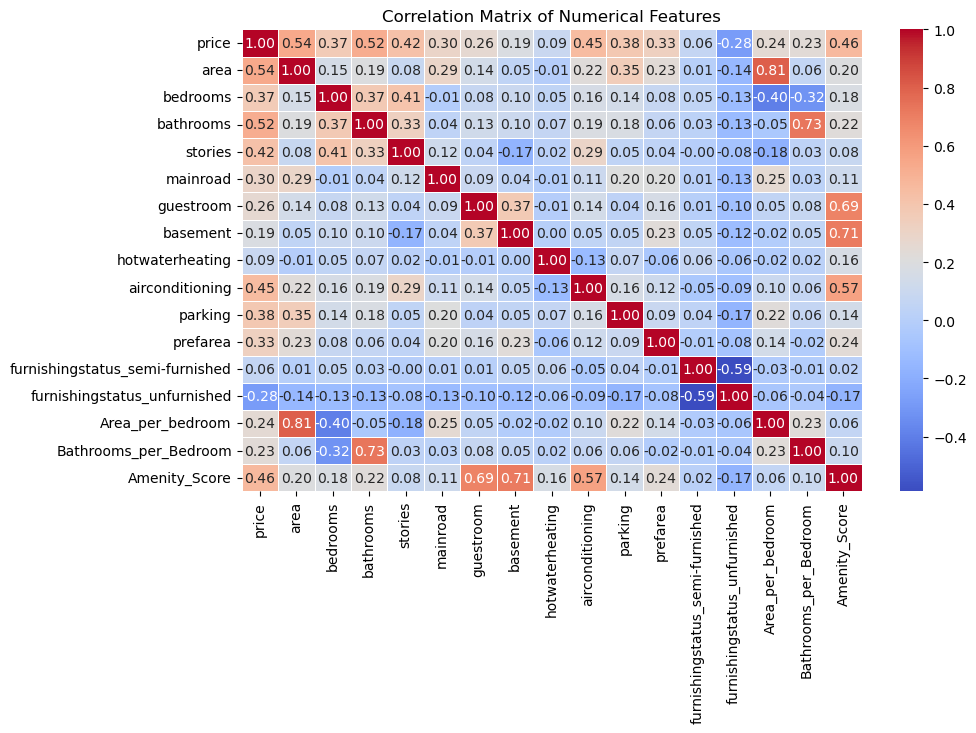

In [19]:
# Select only numerical columns for correlation calculation
numerical_cols = Housing.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = Housing[numerical_cols].corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap for better readability
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

 Observation

The correlation analysis revealed that **Area** and **Bathrooms** exhibited the strongest positive relationships with house price.

Among the engineered features, **Amenity Score** showed a moderate positive correlation with price, suggesting that houses with more amenities generally tend to have higher market values.

Although **Area per Bedroom** and **Bathrooms per Bedroom** displayed weaker correlations with the target variable, they were retained for further evaluation using model-based feature selection techniques.

In [20]:
# Train the Gradient Boosting model
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_pred = gb_model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"MAE: {baseline_mae}")
print(f"MSE: {baseline_mse}")
print(f"RMSE: {baseline_rmse}")
print(f"R²: {baseline_r2}")

MAE: 982432.5098277876
MSE: 1816798379830.3154
RMSE: 1347886.6346359828
R²: 0.6405632346016437


In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [23]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation R²:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation R²:
0.6067288423009244


In [24]:
best_gb = grid_search.best_estimator_

In [25]:
optimized_pred = best_gb.predict(X_test)

optimized_mae = mean_absolute_error(y_test, optimized_pred)
optimized_mse = mean_squared_error(y_test, optimized_pred)
optimized_rmse = np.sqrt(optimized_mse)
optimized_r2 = r2_score(y_test, optimized_pred)

print(f"MAE: {optimized_mae}")
print(f"MSE: {optimized_mse}")
print(f"RMSE: {optimized_rmse}")
print(f"R²: {optimized_r2}")

MAE: 1012327.6901181069
MSE: 1950858410379.934
RMSE: 1396731.3307790924
R²: 0.6140406967763622


In [26]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_gb,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross-validation scores:")
print(cv_scores)

print(f"\nMean CV R²: {cv_scores.mean():.3f}")
print(f"Standard Deviation: {cv_scores.std():.3f}")

Cross-validation scores:
[0.61116212 0.62421584 0.61376779 0.59259513 0.59190333]

Mean CV R²: 0.607
Standard Deviation: 0.013


In [27]:
import joblib

joblib.dump(best_gb, "gradient_boosting_optimized.pkl")

print("Model saved successfully!")

Model saved successfully!


In [28]:
joblib.dump(list(X_train.columns), "model_features.pkl")

print("Feature names saved successfully!")

Feature names saved successfully!


In [29]:
loaded_model = joblib.load("gradient_boosting_optimized.pkl")

print(loaded_model.feature_names_in_)

['area' 'bedrooms' 'bathrooms' 'stories' 'mainroad' 'guestroom' 'basement'
 'hotwaterheating' 'airconditioning' 'parking' 'prefarea'
 'furnishingstatus_semi-furnished' 'furnishingstatus_unfurnished'
 'Area_per_bedroom' 'Bathrooms_per_Bedroom' 'Amenity_Score']


Since the Gradient Boosting model trained on the complete engineered feature set achieved better predictive performance than the model trained on the selected features, the complete feature set was retained for hyperparameter tuning and final model optimization.

Feature importance was extracted from the trained Gradient Boosting model to determine which predictors contributed most to house price prediction. Unlike correlation analysis, this method captures nonlinear relationships learned during model training.

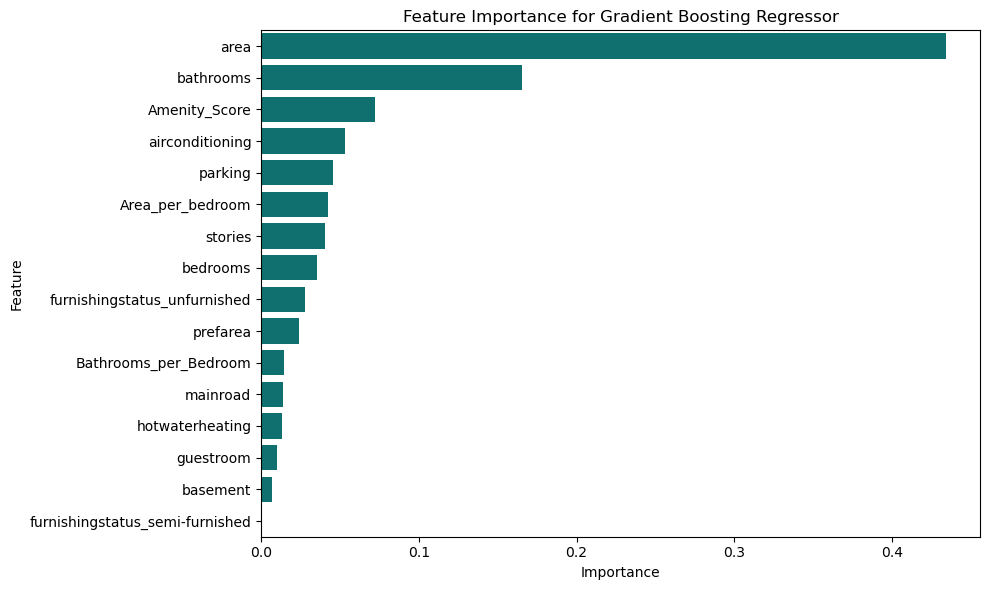

In [30]:
#plot feature importance to determine Which features the model relied on most.
features = X_train.columns
feature_importances = gb_model.feature_importances_ 

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df,color="teal")
plt.title('Feature Importance for Gradient Boosting Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The feature importance analysis showed that Area was the most influential predictor of house price, followed by Bathrooms, Air Conditioning, and Amenity Score. This indicates that both structural characteristics and additional housing amenities contribute substantially to price prediction. These findings complemented the results obtained from correlation analysis and informed the subsequent feature selection process.

# Recursive Feature Elimination (RFE)

Recursive Feature Elimination (RFE) was applied using a Gradient Boosting Regressor as the estimator.

RFE works by recursively removing the least important feature until the desired number of predictors remains.

This method evaluates features within the context of the predictive model rather than considering each feature individually.

In [31]:
# Create the estimator
gb_model = GradientBoostingRegressor(random_state=42)

# Select the top 8 features
rfe = RFE(estimator=gb_model, n_features_to_select=8)

# Fit RFE
rfe.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,n_features_to_select,8
,step,1
,verbose,0
,importance_getter,'auto'
,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2


In [32]:
selected_features = X_train.columns[rfe.support_]

print(f"Selected Features: {selected_features}")


Selected Features: Index(['area', 'bedrooms', 'bathrooms', 'stories', 'airconditioning',
       'parking', 'Area_per_bedroom', 'Amenity_Score'],
      dtype='object')


In [33]:
feature_ranking = pd.DataFrame({
    "Feature": X_train.columns,
    "Selected": rfe.support_,
    "Ranking": rfe.ranking_
})

feature_ranking.sort_values("Ranking")

,Feature,Selected,Ranking
0,area,True,1
1,bedrooms,True,1
2,bathrooms,True,1
3,stories,True,1
8,airconditioning,True,1
9,parking,True,1
13,Area_per_bedroom,True,1
15,Amenity_Score,True,1
12,furnishingstatus_unfurnished,False,2
10,prefarea,False,3


In [34]:

selector = SelectKBest(score_func=f_regression, k=8)

X_new = selector.fit_transform(X_train, y_train)

selected_features = X_train.columns[selector.get_support()]

print(selected_features)

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'airconditioning', 'parking', 'Amenity_Score'],
      dtype='object')


In [35]:
feature_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "Score": selector.scores_})

feature_scores = feature_scores.sort_values(by="Score", ascending=False)

feature_scores

,Feature,Score
0,area,172.961860
2,bathrooms,171.780085
8,airconditioning,123.439412
15,Amenity_Score,123.303650
3,stories,85.163757
9,parking,72.661557
1,bedrooms,69.450455
4,mainroad,44.113414
10,prefarea,42.912514
12,furnishingstatus_unfurnished,34.662821


In [36]:
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train,y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [37]:
y_pre = gb_model.predict(X_test)
y_pre

array([ 4714480.91013798,  7262110.23857118,  3705169.90014623,
        4397582.28291923,  3886963.90332507,  3945448.66646794,
        5881978.51997083,  5765312.87353832,  3278701.62206766,
        2904459.82881246, 11162451.517887  ,  3051886.81079922,
        3065780.68795452,  3380271.82618293,  3695366.05904691,
        3571418.75176434,  3240682.11063933,  5508741.1765722 ,
        4353336.36067099,  4128930.7329459 ,  5731038.5278379 ,
        6011248.85130419,  2962353.03680083,  4504362.28241583,
        4865614.75675904,  7053205.41852629,  3507391.35960646,
        4395546.6714632 ,  6827271.22682936,  3448194.42386308,
        5848247.87620702,  3370926.68539537,  6669284.16863563,
        4179246.011298  ,  3262403.83514954,  6063867.13119671,
        4922212.81867682,  3763382.82623982,  2859308.33159077,
        4192824.55823955,  4547668.67250659,  3060719.35593485,
        7290198.28522089,  4242447.15583094,  3924131.14643246,
        4064756.51711356,  6991007.92404

In [38]:
# Evaluate GradientBoostingRegressor
mae = mean_absolute_error(y_test,y_pre)
mse = mean_squared_error(y_test,y_pre)
r2 = r2_score(y_test, y_pre)
rmse = np.sqrt(mse)

In [39]:
print(f"Mean_Absolute_error: {mae}")
print(f"Mean_squared_error: {mse}")
print(f"r2_score: {r2}")
print(f"RMSE: {rmse}")

Mean_Absolute_error: 982432.5098277876
Mean_squared_error: 1816798379830.3154
r2_score: 0.6405632346016437
RMSE: 1347886.6346359828


In [40]:
train_r2 = gb_model.score(X_train, y_train)
test_r2 = gb_model.score(X_test, y_test)
print(f"Training R²: {train_r2:.3f}")
print(f"Testing R²: {test_r2:.3f}")

Training R²: 0.883
Testing R²: 0.641


In [41]:
selected_features = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "airconditioning",
    "parking",
    "Area_per_bedroom",
    "Amenity_Score"
]

X = Housing[selected_features]
y = Housing["price"]

# Split again using ONLY the selected features
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
# Initialize a new GradientBoostingRegressor model with a fixed random state.
gb_model = GradientBoostingRegressor(random_state=42)

# Train the model using the training data with the selected features.
gb_model.fit(X_train,y_train)
# Make predictions on the test set using the model trained with selected features.
pred_selected = gb_model.predict(X_test)
# Evaluate GradientBoostingRegressor
mae = mean_absolute_error(y_test,pred_selected)
mse = mean_squared_error(y_test,pred_selected)
r2 = r2_score(y_test,pred_selected)
rmse = np.sqrt(mse)
# Print the evaluation metrics for the Gradient Boosting model using selected features.
print(f"Mean_Absolute_error: {mae}")
print(f"Mean_squared_error: {mse}")
print(f"r2: {r2}")
print(f"RMSE: {rmse}")

Mean_Absolute_error: 1010699.6096731935
Mean_squared_error: 1982652700037.1392
r2: 0.6077504904665175
RMSE: 1408067.0083618674


Feature selection using RFE reduced the feature set from the full set of predictors to eight variables. While this simplified the model, it also resulted in a slight decrease in predictive performance (Testing R² decreased from 0.641 to 0.608). This suggests that some of the removed features still contributed useful information to the prediction of house prices. Therefore, the full feature set was retained for the final model optimization.

Hyperparameter Tuning (Gradient Boosting)
Tuning GradientBoostingRegressor using the dataset with all engineered features

In [43]:
# Define the parameter grid
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]}

In [44]:
# Run grid search
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [45]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation R²:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation R²:
0.5859833300005288


In [46]:
best_gb = grid_search.best_estimator_

y_pred = best_gb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

MAE: 1058968.2705818834
MSE: 2089701416145.6199
RMSE: 1445579.9584061822
R²: 0.5865718915172643


In [47]:
train_r2 = best_gb.score(X_train, y_train)
test_r2 = best_gb.score(X_test, y_test)

print(f"Training R²: {train_r2:.3f}")
print(f"Testing R²: {test_r2:.3f}")

Training R²: 0.707
Testing R²: 0.587


Cross-Validation

Five-fold cross-validation was used to evaluate the stability of the optimized Gradient Boosting model.

The model achieved a mean R² score of 0.586 with a standard deviation of 0.025 across the five folds. The relatively small variation between folds indicates that the model performs consistently on different subsets of the training data, suggesting good stability and reasonable generalization ability.

In [48]:
# cross validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_gb,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross-validation scores:")
print(cv_scores)

print(f"\nMean CV R²: {cv_scores.mean():.3f}")
print(f"Standard Deviation: {cv_scores.std():.3f}")

Cross-validation scores:
[0.61372828 0.60843765 0.55850741 0.55394972 0.59529358]

Mean CV R²: 0.586
Standard Deviation: 0.025


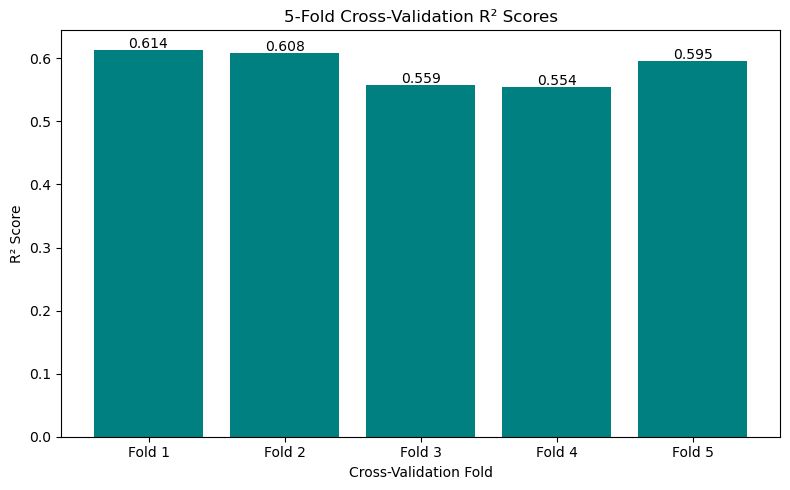

In [49]:
# Fold labels
folds = ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"]

plt.figure(figsize=(8,5))
plt.bar(folds, cv_scores,color="teal")

plt.title("5-Fold Cross-Validation R² Scores")
plt.xlabel("Cross-Validation Fold")
plt.ylabel("R² Score")

# Display values on bars
for i, score in enumerate(cv_scores):
    plt.text(i, score + 0.003, f"{score:.3f}", ha="center")

plt.tight_layout()
plt.show()

Model Performance Comparison

This visualization compares the R² scores of the Gradient Boosting models at different stages of the development process: the initial baseline model (trained with all features), the model trained with features selected by RFE, and the final model after hyperparameter optimization. This helps in understanding the impact of feature engineering, feature selection, and hyperparameter tuning on predictive performance.

C:\Users\windows 10\AppData\Local\Temp\ipykernel_10640\1480235834.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2_Score', data=performance_df, palette='viridis')


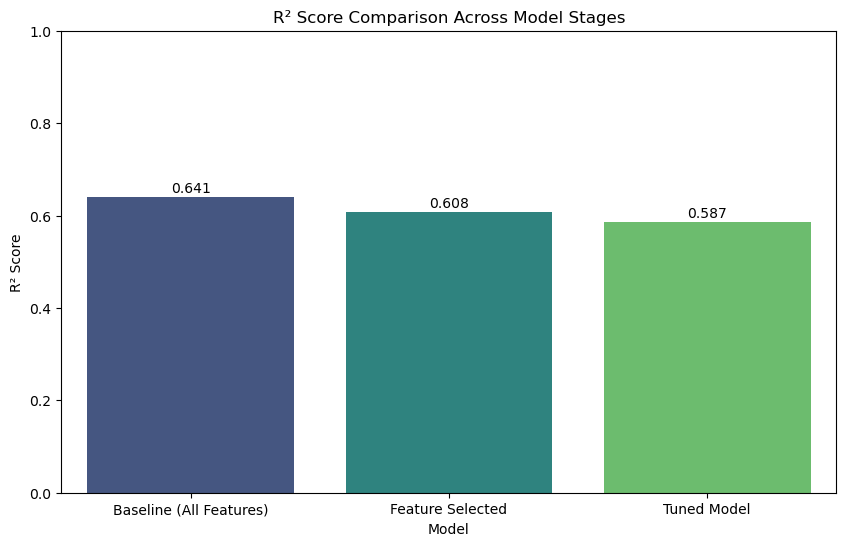

In [50]:
# Store the R² scores for comparison
performance_data = {
    'Model': ['Baseline (All Features)', 'Feature Selected', 'Tuned Model'],
    'R2_Score': [0.641, 0.608, 0.587] # These values are taken from previous cell outputs
}
performance_df = pd.DataFrame(performance_data)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2_Score', data=performance_df, palette='viridis')
plt.title('R² Score Comparison Across Model Stages')
plt.ylabel('R² Score')
plt.ylim(0, 1) # R² score ranges from 0 to 1

# Add R² values on top of the bars for clarity
for index, row in performance_df.iterrows():
    plt.text(row.name, row.R2_Score + 0.01, round(row.R2_Score, 3), color='black', ha="center")

plt.show()


Conclusion

Three engineered features were created to capture additional information about property characteristics: Area_per_Bedroom, Bathrooms_per_Bedroom, and Amenity_Score. Feature selection was performed using Correlation Analysis, Feature Importance, Recursive Feature Elimination (RFE), and SelectKBest. The results showed that several original features, together with Amenity_Score and Area_per_Bedroom, were consistently identified as important predictors.

Gradient Boosting, which achieved the best performance during the Week 5 baseline comparison, was selected for further optimization. Although the engineered features were conceptually meaningful, they did not improve the model's predictive performance on the test set. Hyperparameter tuning using GridSearchCV identified the optimal parameter combination (learning_rate = 0.05, max_depth = 2, min_samples_leaf = 2, min_samples_split = 2, and n_estimators = 100), but the optimized model did not outperform the baseline Gradient Boosting model. Five-fold cross-validation produced a mean R² of 0.586 with a standard deviation of 0.025, indicating consistent model performance across different training folds.

Optimized Model

In [51]:
best_gb

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


In [52]:
# Save final optimized model
import joblib

joblib.dump(
    best_gb,
    "gradient_boosting_optimized.pkl"
)

['gradient_boosting_optimized.pkl']

In [53]:
import joblib

# Save the feature names used to train the model
joblib.dump(list(X_train.columns), "model_features.pkl")

print("Feature names saved successfully!")

Feature names saved successfully!


In [54]:
import os

os.listdir()

['.ipynb_checkpoints',
 'Cleaned_Housing.csv',
 'Feature engineering and model optimization.ipynb',
 'gradient_boosting_optimized.pkl',
 'model_features.pkl']

In [55]:
print(list(X_train.columns))

['area', 'bedrooms', 'bathrooms', 'stories', 'airconditioning', 'parking', 'Area_per_bedroom', 'Amenity_Score']
